In [1]:
import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import densenet121, DenseNet121_Weights
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
# === 1. Device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

# === 2. Label mapping to match Kaggle order ===
kaggle_labels = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']
label_to_idx = {emotion: i for i, emotion in enumerate(kaggle_labels)}

# === 3. Dataset (with class subfolders) ===
class RAFDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform
        self.samples = []

        # Build image path dictionary from subfolders
        self.image_dict = {}
        for class_folder in os.listdir(img_dir):
            class_path = os.path.join(img_dir, class_folder)
            if not os.path.isdir(class_path):
                continue
            for file in os.listdir(class_path):
                if file.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.image_dict[file] = os.path.join(class_path, file)

        # Match CSV image names with actual image paths
        for _, row in self.df.iterrows():
            img_name = row["image"].replace("\\", "/")
            label = int(row["label"]) - 1  # 1-based to 0-based
            if img_name in self.image_dict:
                self.samples.append((self.image_dict[img_name], label))

        print(f"Loaded {len(self.samples)} samples from {csv_path}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [3]:
# === 4. Transforms ===
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# === 5. DataLoaders ===
train_ds = RAFDataset("raf_db_dataset/train_split.csv", "raf_db_dataset/train", train_tf)
val_ds   = RAFDataset("raf_db_dataset/val_split.csv", "raf_db_dataset/train", test_tf)
test_ds  = RAFDataset("raf_db_dataset/test_labels.csv", "raf_db_dataset/test", test_tf)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

Loaded 10430 samples from raf_db_dataset/train_split.csv
Loaded 1841 samples from raf_db_dataset/val_split.csv
Loaded 3068 samples from raf_db_dataset/test_labels.csv


In [4]:
# === 6. Model + Criterion ===
model = densenet121(weights=DenseNet121_Weights.DEFAULT)
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.classifier.in_features, 7)
)
model = model.to(device)

class_counts = np.bincount([lbl for _, lbl in train_ds])
class_weights = torch.tensor(1.0/class_counts, dtype=torch.float).to(device)

# === 7. Optimizer & Scheduler ===
epochs = 50
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=5e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
scaler = torch.cuda.amp.GradScaler()

def mixup_data(x, y, alpha=0.5):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def mixup_criterion(crit, pred, y_a, y_b, lam):
    return lam*crit(pred, y_a)+(1-lam)*crit(pred, y_b)

C:\Users\Kyojuro\AppData\Local\Temp\ipykernel_20756\2695603957.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Train Epoch 1/50:   0%|          | 0/163 [00:00<?, ?it/s]/tmp/ipykernel_1879954/588874219.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Train Epoch 1/50: 100%|██████████| 163/163 [00:26<00:00,  6.19it/s]


Epoch 1: Train Acc 0.4970, Val Acc 0.6855
Saved best model


Train Epoch 2/50: 100%|██████████| 163/163 [00:22<00:00,  7.11it/s]


Epoch 2: Train Acc 0.7085, Val Acc 0.7099
Saved best model


Train Epoch 3/50: 100%|██████████| 163/163 [00:22<00:00,  7.22it/s]


...

Epoch 11: Train Acc 0.5339, Val Acc 0.7968


Train Epoch 12/50: 100%|██████████| 163/163 [00:21<00:00,  7.58it/s]


Epoch 12: Train Acc 0.5249, Val Acc 0.8017


Train Epoch 13/50: 100%|██████████| 163/163 [00:24<00:00,  6.75it/s]


Epoch 13: Train Acc 0.5506, Val Acc 0.7914
Early stopping


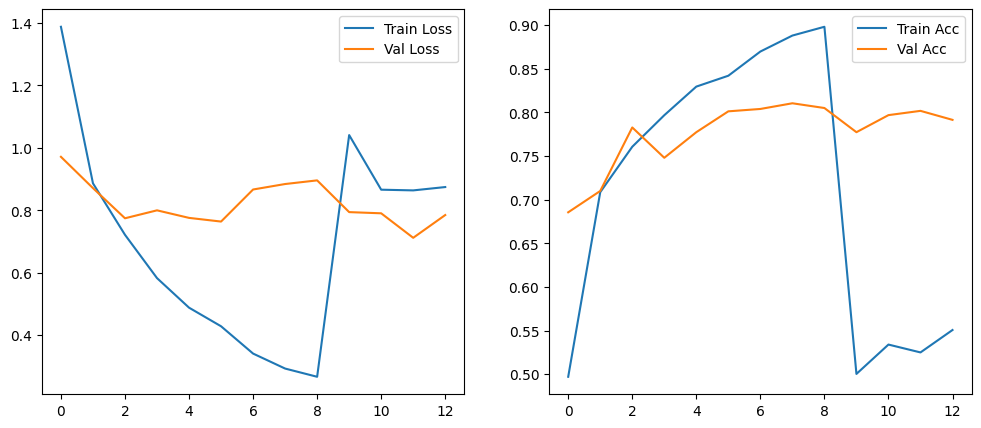

In [5]:
# === 8. Training Loop ===
best_acc, patience, cnt = 0, 5, 0
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for ep in range(1, epochs+1):
    model.train()
    total_loss = 0; correct=0; total=0
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05 if ep>=20 else 0.0)

    for x, y in tqdm(train_loader, desc=f"Train Epoch {ep}/{epochs}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            if ep >= 10:
                xm, ya, yb, lam = mixup_data(x, y)
                out = model(xm)
                loss = mixup_criterion(criterion, out, ya, yb, lam)
            else:
                out = model(x)
                loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    history['train_loss'].append(total_loss/len(train_loader))
    history['train_acc'].append(correct/total)
    scheduler.step()

    # Validation
    model.eval()
    val_loss = 0; correct=0; total=0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    val_acc = correct/total
    history['val_loss'].append(val_loss/len(val_loader))
    history['val_acc'].append(val_acc)

    print(f"Epoch {ep}: Train Acc {history['train_acc'][-1]:.4f}, Val Acc {val_acc:.4f}")
    if val_acc > best_acc:
        best_acc, cnt = val_acc, 0
        torch.save(model.state_dict(), "models/best_densenet121_rafdb.pth")
        print("Saved best model")
    else:
        cnt += 1
        if cnt >= patience:
            print("Early stopping")
            break

# === 9. Plot ===
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend()
plt.show()


Test Accuracy: 0.8227
Test Loss: 32.0548


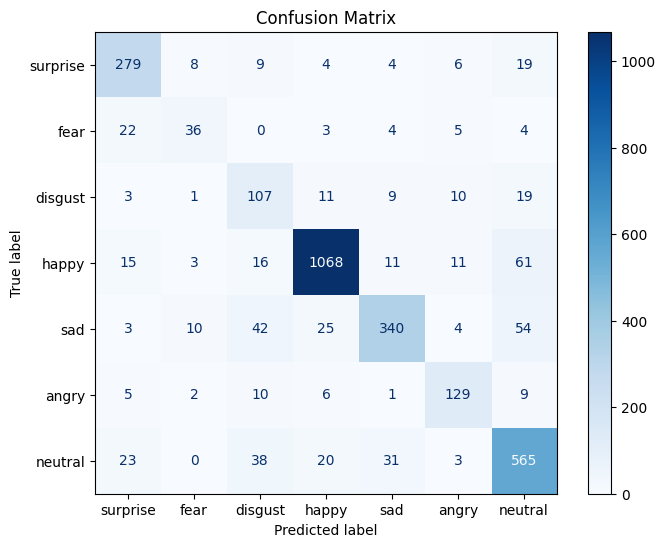

              precision    recall  f1-score   support

    surprise       0.80      0.85      0.82       329
        fear       0.60      0.49      0.54        74
     disgust       0.48      0.67      0.56       160
       happy       0.94      0.90      0.92      1185
         sad       0.85      0.71      0.77       478
       angry       0.77      0.80      0.78       162
     neutral       0.77      0.83      0.80       680

    accuracy                           0.82      3068
   macro avg       0.74      0.75      0.74      3068
weighted avg       0.83      0.82      0.83      3068



In [5]:
# Load best model weights
model.load_state_dict(torch.load("models/best_densenet121_rafdb.pth"))
model.eval()

class_names = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']
# Initialize trackers
all_preds, all_labels = [], []
test_loss, correct, total = 0.0, 0, 0
criterion = nn.CrossEntropyLoss(weight=class_weights)  # recreate loss for test set

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        loss = criterion(outputs, y)
        test_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# === Print Test Performance ===
print(f"\nTest Accuracy: {correct / total:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# === Confusion Matrix ===
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# === Classification Report ===
print(classification_report(all_labels, all_preds, target_names=class_names))

In [11]:
from PIL import Image
import torch.nn.functional as F

# === Define the same transforms used during test/validation ===
inference_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# === Class names in correct order ===
class_names = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']

# === Load model ===
model.load_state_dict(torch.load("models/best_densenet121_rafdb.pth"))
model.eval()

# === Predict single image ===
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = inference_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)
        pred_idx = output.argmax(dim=1).item()
        pred_class = class_names[pred_idx]
        confidence = probs[0][pred_idx].item()

    print(f"Prediction: {pred_class} ({confidence*100:.2f}% confidence)")
    return pred_class, confidence

# === Example Usage ===
image_path = "emotion_dataset/test/happy/PrivateTest_258543.jpg"
predict_image(image_path)


Prediction: happy (98.10% confidence)


('happy', 0.9809587597846985)